# Decision Tree Regression (CART) — Google Colab

**Goal:** Predict a continuous target using **Decision Tree Regression (CART)** — captures **non-linear** patterns with easy-to-read rules.

| Example | Feature(s) (X) | Target (y) | Dataset |
|---------|----------------|------------|---------|
| **Example 1** | YearsExperience | Salary | `../Datasets/experience_salary_large.csv` (200 rows) |
| **Example 2** | Area_sqft, Bedrooms, Age_years | Price | `../Datasets/house_price_large.csv` (250 rows) |

| Phase | Topic | Cells |
|-------|-------|-------|
| Phase 0 | Setup | Install & Imports |
| — | Algorithm Guide | CART definitions, MSE, tree structure |
| Phase 1 | Data Pre-processing | Load → Cleaning → Encoding → Split |
| Phase 2 | Algorithm | Train → Predict → Visualize → Evaluate |

> **Run:** Runtime → Run all (or Ctrl+F9)

---
# Algorithm Guide — Decision Tree Regression (CART)

## What is CART?

**CART** = **Classification And Regression Trees**.  
For regression, the tree splits data to **minimize MSE** and predicts the **average** of y in each leaf.

## Tree Structure

| Part | Name | Role |
|------|------|------|
| **Root** | Root node | First split — top of the tree |
| **Internal node** | Branch | Decision: `feature ≤ threshold?` |
| **Leaf** | Terminal node | Final prediction = **mean(y)** of samples in that leaf |

## How Splitting Works (MSE Criterion)

At each node, CART tries every feature and threshold to find the split that **reduces MSE the most**:

**MSE (Mean Squared Error):**

`MSE = (1/n) · Σ(yᵢ − ȳ)²`

**Split score:** choose the split with the **largest MSE reduction** (greedy algorithm).

## Prediction Rule

1. Start at the **root** node.
2. Follow branches: `if X ≤ threshold` → left, else → right.
3. When you reach a **leaf**, predict `ŷ = mean(y)` of training samples in that leaf.

## Key Hyperparameters

| Parameter | Role | Effect |
|-----------|------|--------|
| `max_depth` | Max tree depth | Shallow = simpler, Deep = overfitting |
| `min_samples_split` | Min samples to split a node | Higher = simpler tree |
| `min_samples_leaf` | Min samples in a leaf | Higher = smoother predictions |
| `max_leaf_nodes` | Max number of leaves | Limits tree complexity |
| `random_state` | Random seed | Reproducible results |

## CART vs Other Models

| | Linear Regression | Decision Tree (CART) |
|---|-------------------|----------------------|
| Shape | Straight line / plane | **Step-like**, non-linear |
| Scaling | Sometimes needed | **Not required** |
| Interpretability | Coefficients | **Visual rules** (if tree is small) |
| Overfitting | Low (simple model) | **High** if tree is too deep |
| Multi-feature | Yes | Yes — splits on any feature |

## What the Student Must Remember

1. CART uses **MSE** to choose splits in regression.
2. Leaf prediction = **average** of y values in that region.
3. **No feature scaling** needed for Decision Trees.
4. Control **`max_depth`** to avoid overfitting.
5. Trees create **step functions** — predictions are constant within each region.

## Phase 0 — Cell 0: Install Libraries

Google Colab usually includes most libraries. This cell ensures required packages are available.

**What this cell does:** Installs scikit-learn, pandas, matplotlib, numpy, and seaborn quietly.

In [38]:
# Install into the same Python as this notebook kernel (avoids pip/kernel mismatch)
import sys
!{sys.executable} -m pip install -q scikit-learn pandas matplotlib numpy



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python3.11 -m pip install --upgrade pip


## Phase 0 — Cell 1: Import Libraries

Import libraries for data handling, preprocessing, modeling, and evaluation.

**What this cell does:** Loads numpy, pandas, matplotlib, sklearn DecisionTreeRegressor, and metrics.

In [39]:
# --- Import libraries ---
import numpy as np              # Numerical operations and arrays
import pandas as pd             # Load and manipulate tabular data
import matplotlib.pyplot as plt # Create charts and plots

from sklearn.model_selection import train_test_split       # Split data into train/test
from sklearn.impute import SimpleImputer                   # Fill missing values
from sklearn.tree import DecisionTreeRegressor, plot_tree  # CART model and tree visualization
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Evaluation metrics

plt.rcParams['figure.figsize'] = (10, 6)  # Default plot size: width=10, height=6 inches
plt.style.use('seaborn-v0_8-whitegrid')   # Clean white background with grid lines
np.random.seed(42)                          # Fix random seed for reproducible splits

print('Libraries ready')                      # Confirm all imports loaded successfully

Libraries ready


---
# Example 1: Experience & Salary — Decision Tree Regression

Predict **Salary** from **YearsExperience**. With **200 rows**, changing `max_depth` clearly affects Train/Test R².

| Column | Role | Description |
|--------|------|-------------|
| `YearsExperience` | Feature (X) | Years of work experience |
| `Salary` | Target (y) | Annual salary in USD |

**File:** `../Datasets/experience_salary_large.csv`

---
# Phase 1: Data Pre-processing

Prepare the data before training — same template is reused for other algorithms.

## Example 1 — Cell 1: Load and Explore Data

Load the CSV file and perform initial exploration (head, info, describe, shape).

**What this cell does:** Reads `../Datasets/experience_salary_large.csv` and displays basic statistics.

In [40]:
# Step 1) Load dataset
dataset = pd.read_csv('../Datasets/experience_salary_large.csv')  # 200 rows — enough for max_depth tuning

FEATURE_COL = 'YearsExperience'   # Independent variable (X) — years of experience
TARGET_COL = 'Salary'   # Dependent variable (y) — salary to predict

print('First 5 rows:')          # Print a label for the table below
display(dataset.head())         # Show the first 5 rows to inspect the data

print('\nDataset info:')       # Print a label for column types and null counts
dataset.info()                  # Show column names, data types, and non-null counts

print('\nStatistical summary:')  # Print a label for numeric statistics
display(dataset.describe())       # Show count, mean, std, min, max, quartiles

print(f'\nShape: {dataset.shape[0]} rows x {dataset.shape[1]} columns')  # Total rows and columns

First 5 rows:


,YearsExperience,Salary
0,5.9,84053
1,14.3,180000
2,11.1,167171
3,9.2,128426
4,2.8,72927



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  200 non-null    float64
 1   Salary           200 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 3.3 KB

Statistical summary:


,YearsExperience,Salary
count,200.000000,200.000000
mean,7.519000,113309.850000
std,4.279792,50998.754102
min,0.600000,28000.000000
25%,3.800000,65734.750000
50%,7.700000,108234.500000
75%,11.500000,168383.500000
max,14.800000,180000.000000



Shape: 200 rows x 2 columns


## Example 1 — Cell 2: Data Cleaning (Handling Missing Values)

Check missing values, remove duplicates, and apply imputation if needed.

**What this cell does:** Cleans the dataset before modeling.

In [41]:
# Step 2) Data cleaning

print('Missing values per column:')  # Print a label
print(dataset.isnull().sum())        # Count NaN values in each column

rows_before = len(dataset)                              # Store row count before cleaning
dataset = dataset.drop_duplicates().reset_index(drop=True)  # Remove duplicate rows
rows_after = len(dataset)                               # Store row count after deduplication
print(f'\nDuplicates removed: {rows_before - rows_after}')  # Show duplicate count

num_cols = dataset.select_dtypes(include=[np.number]).columns.tolist()  # Numeric columns only
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')  # Fill NaN with column mean
if dataset.isnull().sum().sum() > 0:               # If missing values exist
    dataset[num_cols] = imputer.fit_transform(dataset[num_cols])  # Impute numeric columns
    print('Missing values imputed with mean')      # Confirm imputation
else:
    print('No missing values — imputer not applied')  # Skip when complete

print(f'\nRows after cleaning: {rows_after}')    # Final row count

Missing values per column:
YearsExperience    0
Salary             0
dtype: int64

Duplicates removed: 20
No missing values — imputer not applied

Rows after cleaning: 180


## Example 1 — Cell 3: Categorical Data Encoding

`YearsExperience` is numeric — no encoding needed.

**What this cell does:** Checks for categorical columns and encodes if needed.

In [42]:
# Step 3) Categorical encoding

cat_cols = dataset.select_dtypes(include=['object', 'category']).columns.tolist()  # Find text columns
print(f'Categorical columns (not used as X): {cat_cols}')  # Position names — informational only
print(f'Feature used for CART: {FEATURE_COL}')              # Continuous numeric feature
print('No encoding required — X is numeric.')

Categorical columns (not used as X): []
Feature used for CART: YearsExperience
No encoding required — X is numeric.


## Example 1 — Cell 4: Splitting the Data

Define X (YearsExperience) and y (Salary), then split 80/20.

**What this cell does:** Creates feature/target arrays and applies train_test_split.

In [43]:
# Step 4) Train-Test split

X = dataset[[FEATURE_COL]].values  # Feature matrix: YearsExperience (2D array for sklearn)
y = dataset[TARGET_COL].values     # Target vector: Salary values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,                  # Data to split
    test_size=0.2,         # 20% test, 80% train
    random_state=42        # Reproducible split
)

print(f'X_train shape: {X_train.shape}')  # Training features shape
print(f'X_test shape:  {X_test.shape}')   # Test features shape
print(f'y_train shape: {y_train.shape}')  # Training targets shape
print(f'y_test shape:  {y_test.shape}')   # Test targets shape

X_train shape: (144, 1)
X_test shape:  (36, 1)
y_train shape: (144,)
y_test shape:  (36,)


> **Note:** Decision Tree Regression does **not** require feature scaling. Trees split on thresholds — scale does not matter.

---
# Phase 2: Decision Tree Regression (CART)

Train a CART model to predict Salary from YearsExperience.

## Example 1 — Cell 5: Train the Model

Train `DecisionTreeRegressor` — change **`MAX_DEPTH`** below, then **re-run this cell + Predict + Evaluation**.

**Why R² may not change?** Only **8 training rows** → tree maxes out at depth **5** (8 leaves). So `max_depth=5, 10, None` gives the **same** tree and **same** Test R² (~0.60). Try `MAX_DEPTH=1, 2, 3` to see a clear difference.

**What this cell does:** Fits CART and prints depth, leaves, Train R², and Test R².


In [ ]:
# Step 5) Train Decision Tree Regressor (CART)
MAX_DEPTH = 999  # ← Change me: try 1, 2, 3, 4, 5 (then re-run Predict + Evaluation cells)

regressor = DecisionTreeRegressor(
    max_depth=9,   # Max tree depth (lower = simpler, less overfitting)
    min_samples_leaf=1,    # Minimum samples required in a leaf node
    random_state=42        # Reproducible tree structure
)

regressor.fit(X_train, y_train)  # Build tree: find best MSE splits on training data

print('Decision Tree (CART) trained successfully.')
print(f'max_depth setting: {MAX_DEPTH}')
print(f'Actual tree depth: {regressor.get_depth()}')
print(f'Number of leaves: {regressor.get_n_leaves()}')
print(f'Train R²: {r2_score(y_train, regressor.predict(X_train)):.4f}')
print(f'Test R²:  {r2_score(y_test, regressor.predict(X_test)):.4f}')



Decision Tree (CART) trained successfully.
max_depth setting: 999
Actual tree depth: 10
Number of leaves: 77
Train R²: 0.9900
Test R²:  0.9458


## Example 1 — Cell 5b: Compare max_depth Values

See how **Train R²** and **Test R²** change for each `max_depth` (1–8).

**What this cell does:** Trains 8 trees and plots R² vs depth — Test R² flattens after depth 4 on this tiny dataset.


R² by max_depth (same train/test split):


,max_depth,actual_depth,leaves,Train_R2,Test_R2
0,1,1,2,0.7767,0.8051
1,2,2,4,0.9292,0.9222
2,3,3,8,0.9728,0.9556
3,4,4,16,0.9801,0.9530
4,5,5,32,0.9838,0.9496
5,6,6,51,0.9877,0.9457
6,7,7,65,0.9891,0.9454
7,8,8,72,0.9898,0.9462


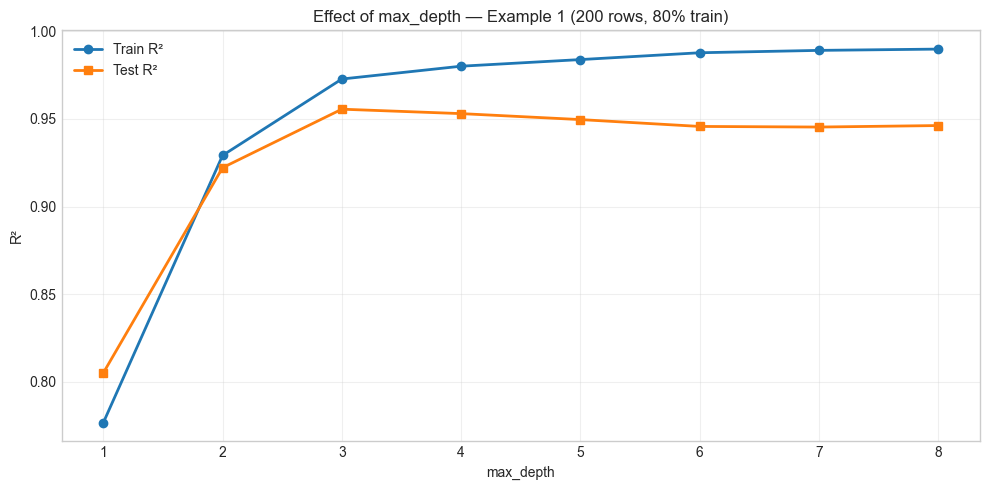

In [45]:
# Step 5b) max_depth comparison — when does R² stop changing?
depth_rows = []
for d in range(1, 9):
    model = DecisionTreeRegressor(max_depth=d, min_samples_leaf=1, random_state=42)
    model.fit(X_train, y_train)
    depth_rows.append({
        'max_depth': d,
        'actual_depth': model.get_depth(),
        'leaves': model.get_n_leaves(),
        'Train_R2': r2_score(y_train, model.predict(X_train)),
        'Test_R2': r2_score(y_test, model.predict(X_test)),
    })

depth_df = pd.DataFrame(depth_rows)
print('R² by max_depth (same train/test split):')
display(depth_df.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depth_df['max_depth'], depth_df['Train_R2'], 'o-', label='Train R²', linewidth=2)
ax.plot(depth_df['max_depth'], depth_df['Test_R2'], 's-', label='Test R²', linewidth=2)
ax.set_xlabel('max_depth')
ax.set_ylabel('R²')
ax.set_title('Effect of max_depth — Example 1 (200 rows, 80% train)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Example 1 — Cell 6: Predict

Predict Salary on the test set.

**What this cell does:** Generates predictions by routing each sample to a leaf.

In [46]:
# Step 6) Predict

y_pred_train = regressor.predict(X_train)  # Predict Salary for training data
y_pred_test = regressor.predict(X_test)    # Predict Salary for test data

print('Sample predictions (Test set):')  # Print a label
for i in range(len(y_test)):             # Show all test predictions
    print(f'  YearsExperience={X_test[i][0]:.1f} -> Actual=${y_test[i]:,.0f}, Predicted=${y_pred_test[i]:,.0f}')

Sample predictions (Test set):
  YearsExperience=4.7 -> Actual=$68,743, Predicted=$62,745
  YearsExperience=13.7 -> Actual=$180,000, Predicted=$180,000
  YearsExperience=3.2 -> Actual=$58,924, Predicted=$63,208
  YearsExperience=9.5 -> Actual=$133,485, Predicted=$137,150
  YearsExperience=3.9 -> Actual=$65,374, Predicted=$73,893
  YearsExperience=3.2 -> Actual=$77,167, Predicted=$63,208
  YearsExperience=7.1 -> Actual=$105,531, Predicted=$110,501
  YearsExperience=3.4 -> Actual=$47,609, Predicted=$59,742
  YearsExperience=8.3 -> Actual=$108,883, Predicted=$121,995
  YearsExperience=12.4 -> Actual=$180,000, Predicted=$180,000
  YearsExperience=8.1 -> Actual=$134,883, Predicted=$112,210
  YearsExperience=3.8 -> Actual=$55,348, Predicted=$63,000
  YearsExperience=0.6 -> Actual=$32,396, Predicted=$37,665
  YearsExperience=4.0 -> Actual=$63,075, Predicted=$73,893
  YearsExperience=5.0 -> Actual=$80,023, Predicted=$61,273
  YearsExperience=4.9 -> Actual=$76,145, Predicted=$71,424
  YearsExpe

## Example 1 — Cell 7: Visualization

Plot the **step function** prediction curve and the **tree structure**.

**What this cell does:** Shows CART step predictions and a visual tree diagram.

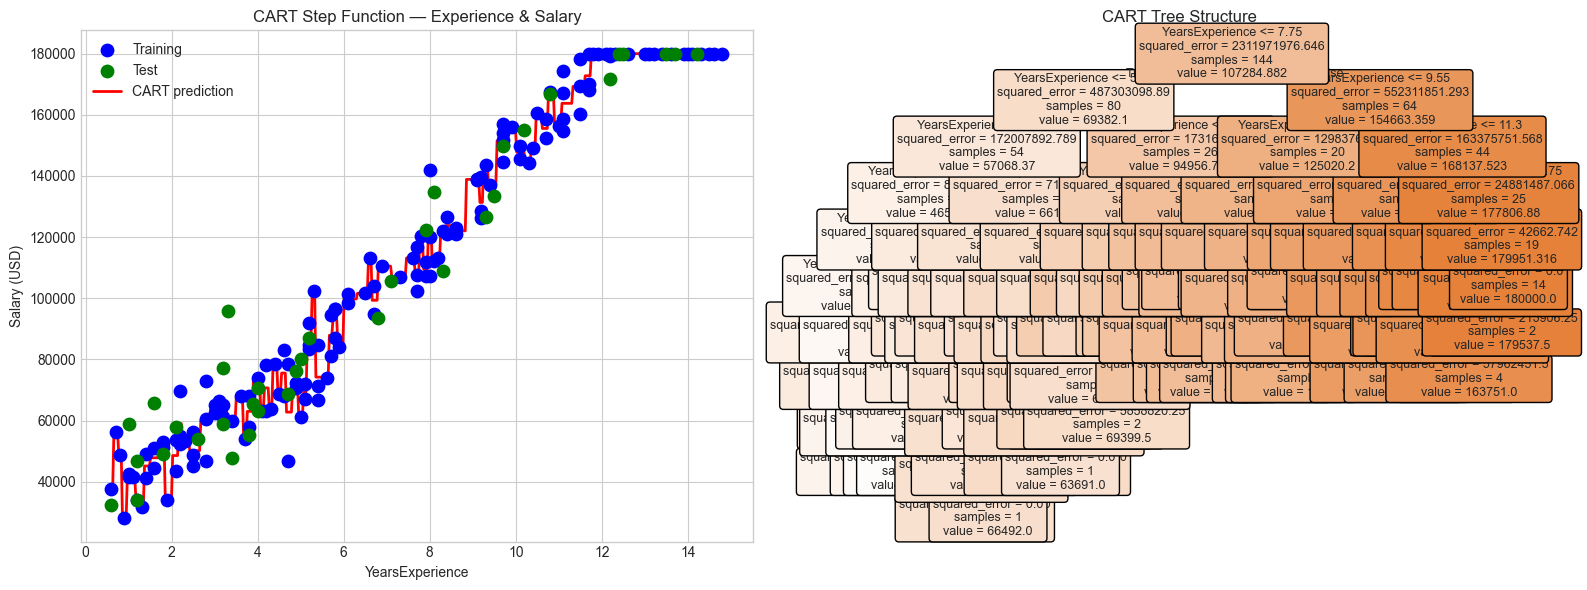

In [47]:
# Step 7) Visualization — step curve + tree diagram

fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # Two subplots: curve and tree

# --- Left: step function curve ---
X_plot = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)  # 500 points for smooth steps
y_plot = regressor.predict(X_plot)                            # CART predictions (step function)

axes[0].scatter(X_train, y_train, color='blue', label='Training', s=80, zorder=3)  # Training points
axes[0].scatter(X_test, y_test, color='green', label='Test', s=80, zorder=3)       # Test points
axes[0].plot(X_plot, y_plot, color='red', linewidth=2, label='CART prediction')    # Step-like curve
axes[0].set_xlabel(FEATURE_COL)             # X-axis label
axes[0].set_ylabel('Salary (USD)')     # Y-axis label
axes[0].set_title('CART Step Function — Experience & Salary')  # Subplot title
axes[0].legend()                        # Show legend

# --- Right: tree diagram ---
plot_tree(
    regressor,                          # Trained CART model
    feature_names=[FEATURE_COL],        # Name shown on split nodes
    filled=True,                        # Color nodes by value
    rounded=True,                       # Rounded node boxes
    fontsize=9,                         # Font size for readability
    ax=axes[1]                          # Draw on second subplot
)
axes[1].set_title('CART Tree Structure')  # Subplot title

plt.tight_layout()  # Adjust spacing
plt.show()          # Display both plots

## Example 1 — Cell 8: Evaluation

Evaluate CART with MAE, RMSE, and R² on the test set.

**What this cell does:** Computes and displays evaluation metrics.

In [48]:
# Step 8) Evaluation
mae = mean_absolute_error(y_test, y_pred_test)              # Mean absolute error in USD
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))     # Root mean squared error
r2 = r2_score(y_test, y_pred_test)                          # Variance explained

results = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Value': [mae, rmse, r2],
    'Description': [
        'Mean Absolute Error (USD)',
        'Root Mean Squared Error (USD)',
        'Coefficient of Determination (1 = perfect)'
    ]
})

display(results.round(4))  # Show metrics table
print(f'\nExample 1 Test R² = {r2:.4f}')  # Print R² summary

,Metric,Value,Description
0,MAE,8360.3157,Mean Absolute Error (USD)
1,RMSE,11275.5378,Root Mean Squared Error (USD)
2,R²,0.9458,Coefficient of Determination (1 = perfect)



Example 1 Test R² = 0.9458


## Why does CART work for Position Salaries?

| # | Reason | Explanation |
|---|--------|-------------|
| 1 | **Non-linear salary jumps** | Salary increases in steps at higher levels — tree splits match this |
| 2 | **No scaling needed** | Trees compare `YearsExperience ≤ threshold` — raw values work fine |
| 3 | **Step function output** | Each leaf predicts a constant salary — fits discrete jumps |
| 4 | **Visual rules** | `plot_tree` shows exact if/else rules students can read |
| 5 | **Tune max_depth** | With 200 rows, compare depths in Cell 5b — shallow vs deep trees |

> **Summary:** CART splits on experience ranges — each leaf predicts average salary in that region.

---
# Example 2: House Price — Decision Tree Regression

Predict **Price** from three property features using CART with **multiple features**.

| Column | Role | Description |
|--------|------|-------------|
| `Area_sqft` | Feature (X₁) | Living area in square feet |
| `Bedrooms` | Feature (X₂) | Number of bedrooms |
| `Age_years` | Feature (X₃) | Age of the house in years |
| `Price` | Target (y) | Sale price in USD |

**File:** `../Datasets/house_price_large.csv`

## Example 2 — Cell 1: Load and Explore Data

Load the house price CSV and inspect the data.

**What this cell does:** Reads `../Datasets/house_price_large.csv` and displays basic statistics.

In [49]:
# Step 1) Load dataset
dataset = pd.read_csv('../Datasets/house_price_large.csv')  # 250 rows

FEATURE_COLS = ['Area_sqft', 'Bedrooms', 'Age_years']  # Three input features
TARGET_COL = 'Price'                                    # Target variable

print('First 5 rows:')
display(dataset.head())

print('\nDataset info:')
dataset.info()

print('\nStatistical summary:')
display(dataset.describe())

print(f'\nShape: {dataset.shape[0]} rows x {dataset.shape[1]} columns')

First 5 rows:


,Area_sqft,Bedrooms,Age_years,Price
0,1506,2,6.5,197361
1,2422,2,9.5,284630
2,911,5,14.8,186622
3,1636,2,6.7,197655
4,722,4,15.6,140146



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Area_sqft  250 non-null    int64  
 1   Bedrooms   250 non-null    int64  
 2   Age_years  250 non-null    float64
 3   Price      250 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 7.9 KB

Statistical summary:


,Area_sqft,Bedrooms,Age_years,Price
count,250.000000,250.000000,250.000000,250.000000
mean,1621.380000,2.984000,12.995600,213861.988000
std,558.171797,1.436663,7.326786,57967.663015
min,722.000000,1.000000,0.300000,90000.000000
25%,1127.250000,2.000000,6.500000,168704.000000
50%,1607.500000,3.000000,13.500000,213249.500000
75%,2073.000000,4.000000,19.650000,257996.250000
max,2599.000000,5.000000,24.900000,372664.000000



Shape: 250 rows x 4 columns


## Example 2 — Cell 2: Data Cleaning (Handling Missing Values)

This dataset includes missing values to demonstrate `SimpleImputer`.

**What this cell does:** Checks for nulls, removes duplicates, and imputes missing values.

In [50]:
# Step 2) Data cleaning

print('Missing values per column:')
print(dataset.isnull().sum())

rows_before = len(dataset)
dataset = dataset.drop_duplicates().reset_index(drop=True)
rows_after = len(dataset)
print(f'\nDuplicates removed: {rows_before - rows_after}')

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
if dataset.isnull().sum().sum() > 0:
    dataset[FEATURE_COLS + [TARGET_COL]] = imputer.fit_transform(dataset[FEATURE_COLS + [TARGET_COL]])
    print('Missing values imputed with mean')
else:
    print('No missing values — imputer not applied')

print(f'\nRows after cleaning: {rows_after}')

Missing values per column:
Area_sqft    0
Bedrooms     0
Age_years    0
Price        0
dtype: int64

Duplicates removed: 0
No missing values — imputer not applied

Rows after cleaning: 250


## Example 2 — Cell 3: Categorical Data Encoding

All columns are numeric — encoding is skipped.

**What this cell does:** Confirms no categorical encoding is needed.

In [51]:
# Step 3) Categorical encoding

cat_cols = dataset.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    print(f'Categorical columns found: {cat_cols}')
else:
    print('No categorical columns — encoding skipped.')
    print(f'Feature columns: {FEATURE_COLS}')

No categorical columns — encoding skipped.
Feature columns: ['Area_sqft', 'Bedrooms', 'Age_years']


## Example 2 — Cell 4: Splitting the Data

Define X (3 features) and y (Price), then split 80/20.

**What this cell does:** Creates feature/target arrays and applies train_test_split.

In [52]:
# Step 4) Train-Test split

X = dataset[FEATURE_COLS].values  # Feature matrix: 3 columns
y = dataset[TARGET_COL].values    # Target vector: Price values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'X_train shape: {X_train.shape}')  # (n_train, 3)
print(f'X_test shape:  {X_test.shape}')   # (n_test, 3)
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape:  {y_test.shape}')

X_train shape: (200, 3)
X_test shape:  (50, 3)
y_train shape: (200,)
y_test shape:  (50,)


## Example 2 — Cell 5: Train the Model

Train CART with multiple features — tree splits on Area, Bedrooms, or Age at each node.

**What this cell does:** Fits the model and reports tree structure.

In [53]:
# Step 5) Train Decision Tree Regressor (CART)

regressor = DecisionTreeRegressor(
    max_depth=5,           # Limit depth for generalization
    min_samples_split=4,   # Need at least 4 samples to split a node
    min_samples_leaf=2,    # Each leaf must have at least 2 samples
    random_state=42
)

regressor.fit(X_train, y_train)  # Build tree using MSE criterion on all 3 features

print('Decision Tree (CART) trained successfully.')
print(f'Tree depth: {regressor.get_depth()}')
print(f'Number of leaves: {regressor.get_n_leaves()}')

print('\nFeature importances:')  # Which features were used most for splitting
for name, imp in zip(FEATURE_COLS, regressor.feature_importances_):
    print(f'  {name:15s} -> {imp:.4f}')  # Higher = more important for splits

Decision Tree (CART) trained successfully.
Tree depth: 5
Number of leaves: 31

Feature importances:
  Area_sqft       -> 0.8977
  Bedrooms        -> 0.0506
  Age_years       -> 0.0517


## Example 2 — Cell 6: Predict

Predict house prices on the test set.

**What this cell does:** Generates predictions by routing samples through the tree.

In [54]:
# Step 6) Predict

y_pred_train = regressor.predict(X_train)
y_pred_test = regressor.predict(X_test)

print('Sample predictions (Test set):')
for i in range(min(5, len(y_test))):
    print(f'  Actual=${y_test[i]:,.0f}, Predicted=${y_pred_test[i]:,.0f}')

Sample predictions (Test set):
  Actual=$262,000, Predicted=$241,066
  Actual=$157,342, Predicted=$147,146
  Actual=$256,889, Predicted=$249,501
  Actual=$296,449, Predicted=$310,520
  Actual=$174,341, Predicted=$156,460


## Example 2 — Cell 7: Visualization

Plot **Actual vs Predicted** and **feature importances**.

**What this cell does:** Visualizes model performance and which features matter most.

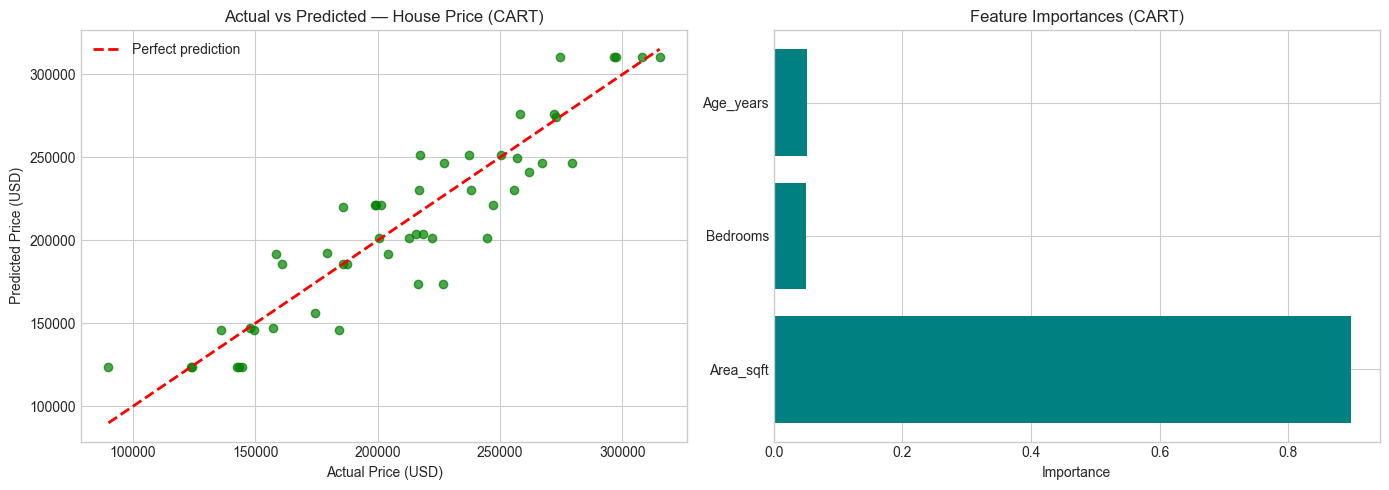

In [55]:
# Step 7) Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # Two subplots

axes[0].scatter(y_test, y_pred_test, color='green', alpha=0.7)  # Actual vs predicted
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price (USD)')
axes[0].set_ylabel('Predicted Price (USD)')
axes[0].set_title('Actual vs Predicted — House Price (CART)')
axes[0].legend()

axes[1].barh(FEATURE_COLS, regressor.feature_importances_, color='teal')  # Feature importance chart
axes[1].set_xlabel('Importance')
axes[1].set_title('Feature Importances (CART)')

plt.tight_layout()
plt.show()

## Example 2 — Cell 8: Evaluation

Evaluate CART performance with MAE, RMSE, and R².

**What this cell does:** Computes and displays evaluation metrics.

In [56]:
# Step 8) Evaluation
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2 = r2_score(y_test, y_pred_test)

results = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Value': [mae, rmse, r2],
    'Description': [
        'Mean Absolute Error (USD)',
        'Root Mean Squared Error (USD)',
        'Coefficient of Determination (1 = perfect)'
    ]
})

display(results.round(4))
print(f'\nExample 2 Test R² = {r2:.4f}')

,Metric,Value,Description
0,MAE,17427.1153,Mean Absolute Error (USD)
1,RMSE,21696.1186,Root Mean Squared Error (USD)
2,R²,0.8320,Coefficient of Determination (1 = perfect)



Example 2 Test R² = 0.8320


## Why does CART work well for House Price?

| # | Reason | Explanation |
|---|--------|-------------|
| 1 | **Multiple features** | CART splits on Area, Bedrooms, and Age automatically |
| 2 | **Non-linear interactions** | e.g. large Area + many Bedrooms → higher Price region |
| 3 | **Feature importances** | Shows which feature contributes most to splits |
| 4 | **No scaling needed** | Raw sqft, bedroom count, and age work directly |
| 5 | **High R² possible** | With tuned `max_depth`, CART fits complex price patterns |

> **Compare:** CART vs Linear Regression — trees capture **non-linear** and **interaction** effects without manual feature engineering.